# BA820: Milestone II

**Course:** BA820 - Unsupervised and Unstructured Machine Learning  
**Author:** Riya Poojary

**Dataset:** Hollywood Age Gaps (age_gaps.csv)  


---

## Executive Summary

This notebook demonstrates question-driven **exploratory data analysis (EDA)** on the **Hollywood Age Gaps** dataset, which captures on-screen couples, actor ages, and gender pairings across films and time.

**The goals are to:**

* build domain understanding before selecting algorithms
* uncover patterns that motivate a clear research question about age gaps and gender pairing
* verify whether unsupervised methods (e.g., clustering) are feasible and meaningful for this dataset


## Table of Contents

### PART I: HOLLYWOOD AGE GAPS
1. Temporal Patterns  
2. Pairing Heterogeneity  
3. Casting Dynamics
4. Summary: Research Questions

### PART II: EDA & Preprocessing: Updates
1. Sanity Check  
2. Preprocessing Update: Focus dataset for reliable comparison
3. Quantify tails/outliers in age gaps (noise)
4. Main comparison (man–woman vs woman–man)

### PART III: Analysis & Experiments
1. Method 1 (Unsupervised): K-means clustering of age-gap “regimes”
2. Method 2 (Unsupervised): Hierarchical clustering as a robustness check

### PART IV: Next Steps

### PART V: Conclusion


In [82]:
# Install packages
!pip install -q seaborn>=0.12.0 scikit-learn>=1.2.0

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


In [83]:
# Helper functions

def basic_overview(df, name="Dataset"):
    print(f"===== {name} =====")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Duplicate rows: {df.duplicated().sum():,}")
    print("\nMissing values (top 10):")
    miss = df.isna().sum().sort_values(ascending=False)
    miss = miss[miss > 0].head(10)
    if len(miss) == 0:
        print("No missing values.")
    else:
        display(miss.to_frame("missing_count"))

def dataset_summary_table(df):
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean()*100).round(2),
        "n_unique": df.nunique(dropna=True)
    }).sort_values(["missing_%","n_unique"], ascending=[False, False])
    return summary

def safe_read_csv(path_or_name):

    candidates = [
        path_or_name,
        os.path.join("/content", path_or_name),
    ]
    for p in candidates:
        if os.path.exists(p):
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"Could not find {path_or_name}. If running in Colab, upload the CSVs first."
    )


---
# PART I: HOLLYWOOD AGE GAPS

## Dataset Overview & Research Motivation

### Dataset: age_gaps.csv

**What it captures:**  
Each row is an **on-screen couple** in a movie, with actor ages, character genders and the age difference.

**Why this dataset?**
- Real, interpretable topic: media representation + casting patterns
- Natural “grouping” questions (era patterns, pairing types, movie archetypes)
- Suitable for unsupervised learning at the **movie level** (cluster movies by relationship patterns)

### Key variables
- release_year (time)
- age_difference (main outcome of interest)
- actor_1_age, actor_2_age (older vs younger actor)
- character_1_gender, character_2_gender (pairing type)
- movie_name, director, couple_number (identifiers)


In [84]:
# Load dataset
age = safe_read_csv("/content/age_gaps.csv")

basic_overview(age, "Hollywood Age Gaps")
display(age.head())
display(dataset_summary_table(age))


===== Hollywood Age Gaps =====
Shape: 1,155 rows × 13 columns
Duplicate rows: 0

Missing values (top 10):
No missing values.


,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38


,column,dtype,missing,missing_%,n_unique
movie_name,movie_name,object,0,0.0,830
actor_2_name,actor_2_name,object,0,0.0,647
actor_2_birthdate,actor_2_birthdate,object,0,0.0,640
actor_1_name,actor_1_name,object,0,0.0,567
actor_1_birthdate,actor_1_birthdate,object,0,0.0,562
director,director,object,0,0.0,510
release_year,release_year,int64,0,0.0,82
actor_1_age,actor_1_age,int64,0,0.0,59
age_difference,age_difference,int64,0,0.0,46
actor_2_age,actor_2_age,int64,0,0.0,45


## 1. Temporal Patterns

**Research Question 1:**  
Do age gaps change over time  and can we identify “eras” or trajectories where movies show different age-gap patterns?

**What we check here:**
- trend in average age gap by year
- distribution shifts over time (decades)


,release_year,count,mean,median,std
0,1935,2,13.000000,13.0,8.485281
1,1936,1,21.000000,21.0,NaN
2,1937,3,7.333333,9.0,5.686241
3,1939,1,12.000000,12.0,NaN
4,1940,3,11.333333,10.0,9.073772


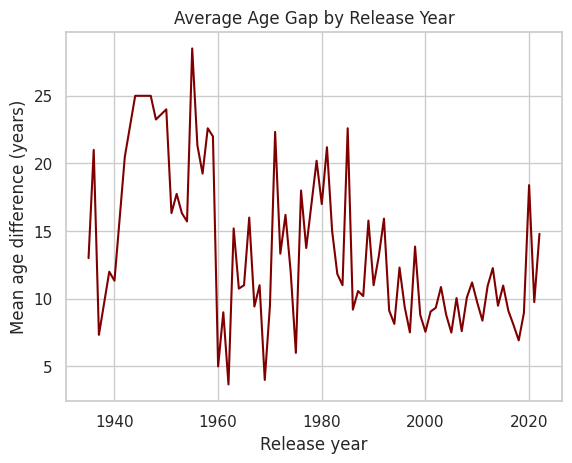

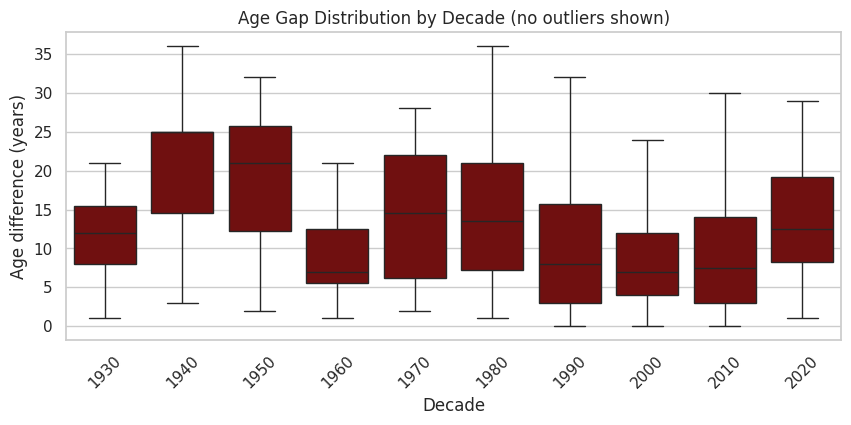

In [85]:
# Mean age gap trend by year
year_stats = age.groupby("release_year")["age_difference"].agg(["count","mean","median","std"]).reset_index()
display(year_stats.head())

plt.figure()
plt.plot(year_stats["release_year"], year_stats["mean"], color= "maroon")
plt.title("Average Age Gap by Release Year")
plt.xlabel("Release year")
plt.ylabel("Mean age difference (years)")
plt.show()

# Decade-based distribution
age["decade"] = (age["release_year"] // 10) * 10

plt.figure(figsize=(10,4))
sns.boxplot(data=age, x="decade", y="age_difference", showfliers=False, color= "maroon")
plt.title("Age Gap Distribution by Decade (no outliers shown)")
plt.xlabel("Decade")
plt.ylabel("Age difference (years)")
plt.xticks(rotation=45)
plt.show()

**Interpretation:**
- Age gaps are higher earlier (1940s–50s) and generally lower in later decades (1990s–2010s).
- The decade boxplots show the “typical” gap (median) shifts downward over time, even if some decades bounce a bit.
- Year-by-year averages are noisy (few movies in some years), so the decade boxplots are more reliable for the overall pattern.


## 2. Pairing Heterogeneity

**Research Question 2:**  
Do different gender pairings have systematically different age-gap patterns?

**Why it matters:**
- If pairings have very different distributions, we can treat them as different archetypes
- This supports clustering movies based on composition of relationship types


,pairing,count,pct
0,man–woman,929,80.4
1,woman–man,203,17.6
2,man–man,12,1.0
3,woman–woman,11,1.0


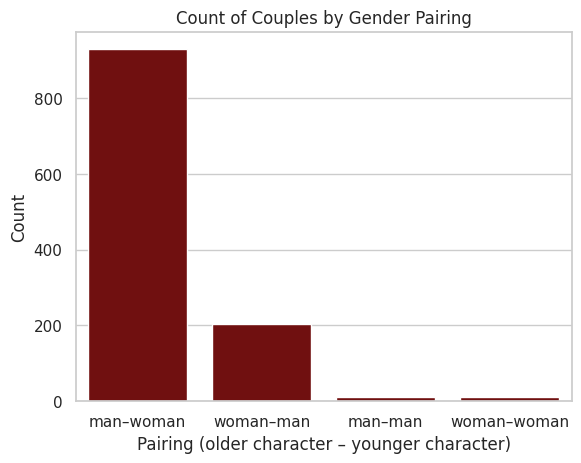

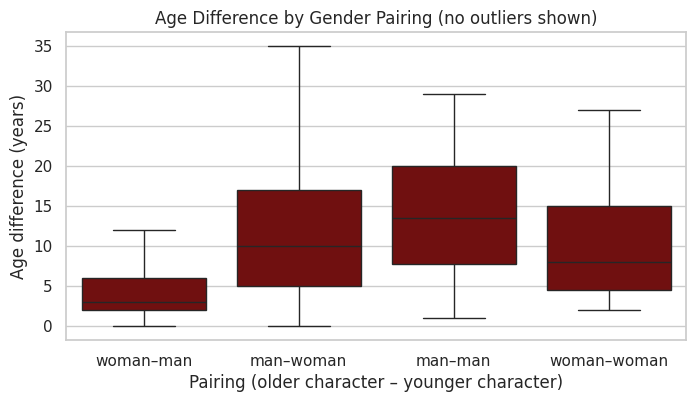

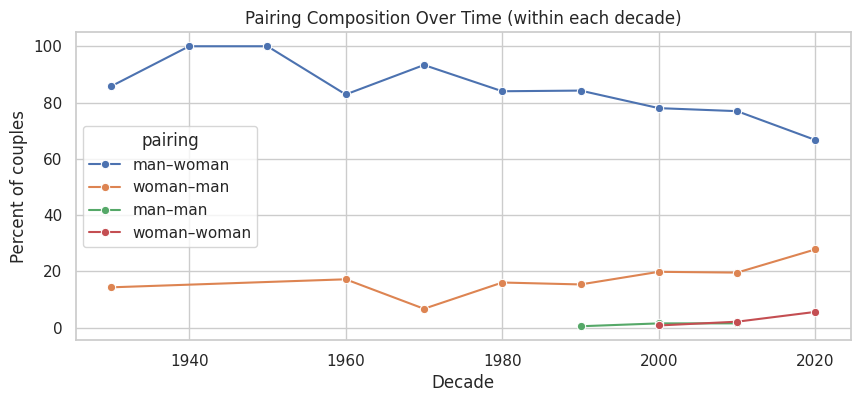

In [86]:
age["pairing"] = (
    age["character_1_gender"].astype(str).str.strip().str.lower()
    + "–" +
    age["character_2_gender"].astype(str).str.strip().str.lower()
)

age["decade"] = (age["release_year"] // 10) * 10

# Pairing counts
pair_counts = age["pairing"].value_counts().rename_axis("pairing").reset_index(name="count")
pair_counts["pct"] = (pair_counts["count"]/len(age)*100).round(1)
display(pair_counts)

plt.figure()
sns.barplot(data=pair_counts, x="pairing", y="count", color= "maroon")
plt.title("Count of Couples by Gender Pairing")
plt.xlabel("Pairing (older character – younger character)")
plt.ylabel("Count")
plt.show()

# Age gap distributions by pairing
plt.figure(figsize=(8,4))
sns.boxplot(data=age, x="pairing", y="age_difference", showfliers=False, color= "maroon")
plt.title("Age Difference by Gender Pairing (no outliers shown)")
plt.xlabel("Pairing (older character – younger character)")
plt.ylabel("Age difference (years)")
plt.show()

# Pairing mix over decades (composition)
mix = (
    age.groupby(["decade","pairing"])
       .size()
       .reset_index(name="n")
)
mix["pct_within_decade"] = mix.groupby("decade")["n"].transform(lambda x: x/x.sum()*100)

plt.figure(figsize=(10,4))
sns.lineplot(data=mix, x="decade", y="pct_within_decade", hue="pairing", marker="o")
plt.title("Pairing Composition Over Time (within each decade)")
plt.xlabel("Decade")
plt.ylabel("Percent of couples")
plt.show()


**Interpretation:**
- Most couples are man–woman and other pairings are much fewer (same-gender is tiny), so comparisons are strongest for man–woman vs woman–man.

- Here, man–woman has larger and wider age gaps and woman–man is smaller and tighter.

- Changes over time: man–woman% declines, woman–man% rises by decade, so movies differ in “pairing mix” which supports clustering by composition.


## 3. Casting Dynamics

**Research Question 3:**  
Are large age gaps mainly driven by very old lead actors paired with much younger partners?  

**Research Question 4:**  
Do some directors/movies consistently show larger gaps?

**What we check here:**
- relationship between actor_1_age and age_difference
- top directors by average age gap
- movies with multiple couples


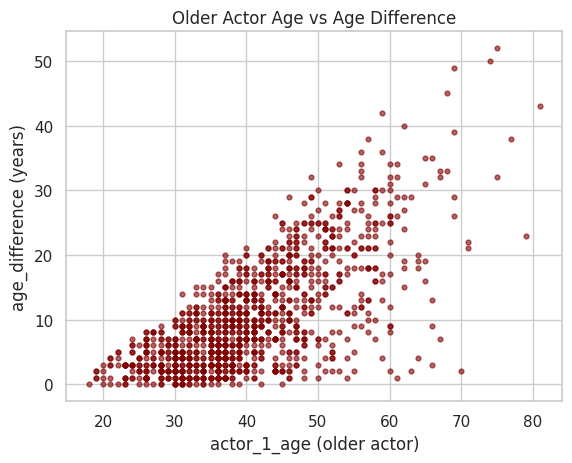

,director,n,avg_gap,med_gap
413,Roger Michell,3,30.000000,33.0
123,Eli Roth,3,22.000000,24.0
13,Alfred Hitchcock,7,21.000000,22.0
317,Michel Gondry,3,20.666667,15.0
202,Jerry Zucker,3,20.333333,16.0
504,Woody Allen,20,20.150000,18.5
217,John Glen,15,19.866667,21.0
171,Howard Hawks,4,19.250000,24.5
236,Jonathan Lynn,4,19.250000,19.0
209,Joel Coen,5,19.000000,11.0


,movie_name,n_couples
0,Love Actually,7
1,The Family Stone,6
2,Mona Lisa Smile,5
3,He's Just Not That Into You,5
4,A View to a Kill,5
5,A Star Is Born,4
6,Sex and the City,4
7,The Favourite,4
8,Boogie Nights,4
9,The Girl on the Train,4


,movie_name,release_year,director,actor_1_name,actor_1_age,actor_2_name,actor_2_age,pairing,age_difference
0,Harold and Maude,1971,Hal Ashby,Ruth Gordon,75,Bud Cort,23,woman–man,52
1,Venus,2006,Roger Michell,Peter O'Toole,74,Jodie Whittaker,24,man–woman,50
2,The Quiet American,2002,Phillip Noyce,Michael Caine,69,Do Thi Hai Yen,20,man–woman,49
3,The Big Lebowski,1998,Joel Coen,David Huddleston,68,Tara Reid,23,man–woman,45
4,Beginners,2010,Mike Mills,Christopher Plummer,81,Goran Visnjic,38,man–man,43
5,Poison Ivy,1992,Katt Shea,Tom Skerritt,59,Drew Barrymore,17,man–woman,42
6,Whatever Works,2009,Woody Allen,Larry David,62,Evan Rachel Wood,22,man–woman,40
7,Entrapment,1999,Jon Amiel,Sean Connery,69,Catherine Zeta-Jones,30,man–woman,39
8,Husbands and Wives,1992,Woody Allen,Woody Allen,57,Juliette Lewis,19,man–woman,38
9,Magnolia,1999,Paul Thomas Anderson,Jason Robards,77,Julianne Moore,39,man–woman,38


In [87]:
# Relationship: older actor age vs age gap
plt.figure()
plt.scatter(age["actor_1_age"], age["age_difference"], s=12, alpha=0.6, color= "maroon")
plt.title("Older Actor Age vs Age Difference")
plt.xlabel("actor_1_age (older actor)")
plt.ylabel("age_difference (years)")
plt.show()

# Top directors by average age gap
dir_stats = (
    age.groupby("director")["age_difference"]
       .agg(n="size", avg_gap="mean", med_gap="median")
       .reset_index()
)
dir_stats = dir_stats[dir_stats["n"] >= 3].sort_values("avg_gap", ascending=False)
display(dir_stats.head(15))

# Movies with multiple couples recorded
movie_couples = age.groupby("movie_name")["couple_number"].nunique().sort_values(ascending=False)
multi = movie_couples[movie_couples > 1].head(15).rename_axis("movie_name").reset_index(name="n_couples")
display(multi)

# Show the biggest gaps
top_gaps = age.sort_values("age_difference", ascending=False).head(15)[
    ["movie_name","release_year","director","actor_1_name","actor_1_age","actor_2_name","actor_2_age","pairing","age_difference"]
]
display(top_gaps)


**Interpretation:**
- Larger age gaps mostly appear when the older lead actor is much older (often 60–80), while younger leads rarely show extreme gaps.

- A few directors/movies show high average/median gaps, but many of these cases have small sample sizes, so treat them as “signals to investigate,” not firm conclusions.

- Movies with multiple couples contribute many rows, so they can disproportionately shape overall patterns compared to movies with only one couple.

## Summary: Research Questions

**What this EDA confirms so far:**

- Age gaps vary across decades, suggesting meaningful time patterns that could support era-based grouping.

- Gender pairings show clearly different age-gap distributions, suggesting distinct relationship “archetypes” rather than one shared pattern.




----
# PART II: EDA & Preprocessing: Updates
##Milestone 1:

**Main EDA result:** Age-gap patterns differ by gender pairing and the dataset is heavily skewed toward mixed-gender pairings (strong class imbalance).

**Validation (reliability):** Across all 1,155 rows, `actor_1_age` is always the older (or same-age) actor and `age_difference` = `actor_1_age` − `actor_2_age`, so pairing can be read as older partner gender → younger partner gender.

**Distribution issue:** `age_difference` is right-skewed with outliers (median 8, max 52; ~2.34% above the IQR upper fence of 31.5), motivating robust summaries (median/IQR) and distribution-focused plots over means.

##Milestone 2:

**Preprocessing update:** Created a targeted analysis subset `age_main` to support stable comparisons.

**Filtering decision:** Same-gender pairings are extremely rare (~1% each), so `age_main` keeps only the two groups with enough data: man–woman (n=929) and woman–man (n=203), total n=1,132.

**Reporting approach:** No scaling/transformations needed since `age_difference` is already on a consistent numeric scale, results focus on medians and distribution visuals to avoid over-emphasizing extreme values.

## 1. Sanity Check
Before comparing age-gap patterns by pairing type, I verify two assumptions:
1) Actor 1 is always the older (or same-age) actor in the pair.
2) `age_difference` matches the absolute difference between `actor_1_age` and `actor_2_age`.

This ensures that pairing labels can be interpreted as older partner gender → younger partner gender and that the age-gap metric is reliable.

In [88]:
# 1) Is actor_1 always older (or equal)?
violations = age[age["actor_1_age"] < age["actor_2_age"]]
print("Rows where actor_1_age < actor_2_age:", len(violations))

# 2) Does age_difference match abs(actor_1_age - actor_2_age)?
check_diff = (age["actor_1_age"] - age["actor_2_age"]).abs()
mismatch = (check_diff - age["age_difference"]).abs()

len(mismatch)
print("Max mismatch between computed gap and age_difference:", mismatch.max())
print("Mismatch summary:")
display(mismatch.describe())


Rows where actor_1_age < actor_2_age: 0
Max mismatch between computed gap and age_difference: 0
Mismatch summary:


,0
count,1155.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


**Interpretation:**

- There are 0 cases where `actor_1_age < actor_2_age`, and the maximum mismatch between the computed age gap and `age_difference` is 0.  

- Therefore, no correction is needed for age-gap calculation and pairing labels can be interpreted as older partner gender → younger partner gender.

##2. Preprocessing Update: Focus dataset for reliable comparison

The proposal EDA showed strong class imbalance across pairing types (same-gender pairings are rare).  
To make distribution comparisons more reliable, I create a focused analysis dataset containing only the two pairing categories with sufficient observations: **man–woman** and **woman–man**.


In [89]:
age_main = age[age["pairing"].isin(["man–woman", "woman–man"])].copy()

print("Main analysis dataset rows:", len(age_main))
print("Counts inside age_main:")
display(age_main["pairing"].value_counts())

Main analysis dataset rows: 1132
Counts inside age_main:


,count
pairing,
man–woman,929
woman–man,203


**Interpretation:**

- The focused dataset contains **1,132** observations: **929** man–woman and **203** woman–man.  This confirms that the main comparison is supported by substantial sample sizes.

- Same-gender pairings remain in the full dataset but will be discussed **descriptively only** because their sample sizes are too small for strong distribution claims.

- This filtering removes **23** observations (the man–man and woman–woman rows), which are the low-sample categories identified in the proposal EDA.

##3. Quantify tails/outliers in age gaps (noise)
Age-gap values can have a long right tail, where a small number of very large gaps can distort averages and make groups look more different than they are.  
To understand the shape of the age-gap distribution, I summarize key quantiles of `age_difference` and use an IQR-based rule to estimate the share of unusually large age gaps (“high outliers”).  
This EDA motivates using robust summaries (median/IQR) and distribution-focused plots.


In [90]:
print("Age difference quantiles:")
display(age["age_difference"].quantile([0, .25, .5, .75, .90, .95, .99, 1]).to_frame("age_difference"))

# IQR rule (simple outlier diagnostic)
q1 = age["age_difference"].quantile(0.25)
q3 = age["age_difference"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

outlier_share = (age["age_difference"] > upper_fence).mean()

print(f"Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, upper fence={upper_fence:.2f}")
print(f"Share of rows above upper fence: {outlier_share:.2%}")


Age difference quantiles:


,age_difference
0.00,0.00
0.25,4.00
0.50,8.00
0.75,15.00
0.90,23.00
0.95,27.00
0.99,35.46
1.00,52.00


Q1=4.00, Q3=15.00, IQR=11.00, upper fence=31.50
Share of rows above upper fence: 2.34%


**Interpretation:**

- Age gaps are right-skewed, most couples have small/moderate gaps (median 8, 75th percentile 15), but a few are very large (up to 52).

- Using the IQR rule, “high outliers” start around 31.5 years and only ~2.34% of rows exceed this rare, but they can inflate means, so median/IQR + boxplots are more reliable for comparisons.

##4. Main comparison (man–woman vs woman–man)

Based on the earlier imbalance finding, same-gender pairings have too few observations to support strong distribution comparisons.  
To make a reliable comparison, I filter the dataset to the two pairing types with sufficient sample sizes: **man–woman** and **woman–man**.  
I then summarize the age-gap distribution for these groups and visualize the typical (median) age gap using a bar chart.


age_main rows: 1132


,count
pairing,
man–woman,929
woman–man,203


,pairing,n,mean,median,std
0,man–woman,929,11.536060,10.0,8.450607
1,woman–man,203,5.009852,3.0,6.064007


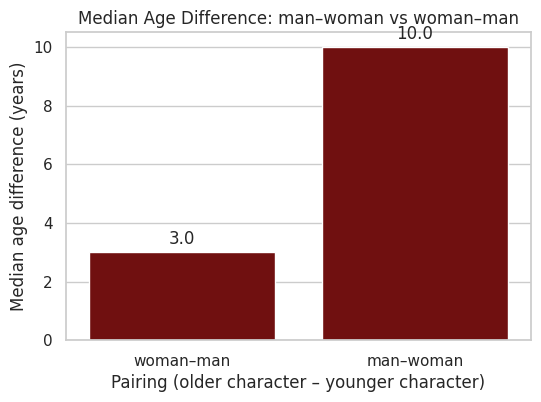

In [91]:
# Focus analysis on the two groups with enough sample size

age_main = age[age["pairing"].isin(["man–woman", "woman–man"])].copy()

print("age_main rows:", len(age_main))
display(age_main["pairing"].value_counts().to_frame("count"))

# Simple summary table (distribution-focused)
main_summary = (
    age_main.groupby("pairing")["age_difference"]
    .agg(n="count", mean="mean", median="median", std="std")
    .reset_index()
)
display(main_summary)

# Plot just the two main groups
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=age_main,
    x="pairing",
    y="age_difference",
    estimator=np.median,
    errorbar=None,
    color= "maroon",
    order=["woman–man", "man–woman"]
)
plt.title("Median Age Difference: man–woman vs woman–man")
plt.xlabel("Pairing (older character – younger character)")
plt.ylabel("Median age difference (years)")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center", va="bottom",
        xytext=(0, 3), textcoords="offset points"
    )

plt.show()

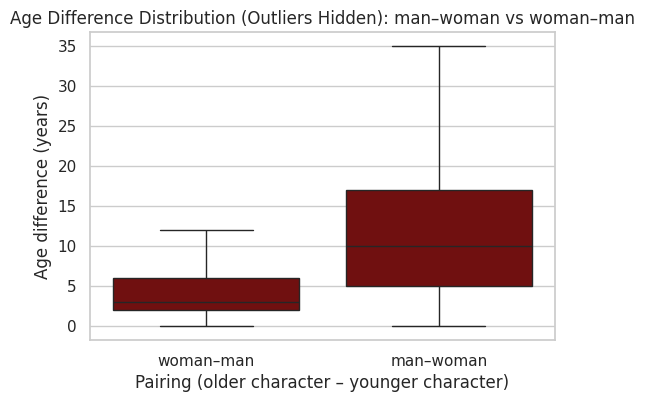

In [94]:
plt.figure(figsize=(6,4))
sns.boxplot(data=age_main, x="pairing", y="age_difference", showfliers=False,color= "maroon",
            order=["woman–man","man–woman"])
plt.title("Age Difference Distribution (Outliers Hidden): man–woman vs woman–man")
plt.xlabel("Pairing (older character – younger character)")
plt.ylabel("Age difference (years)")
plt.show()


**Interpretation:**

The boxplot supports the same conclusion while showing the full distribution. In the focused dataset (1,132 observations: 929 man–woman and 203 woman–man), the man–woman group is shifted upward compared to the woman–man group. The median age gap is higher for man–woman pairings (10 years) than for woman–man pairings (3 years) and the spread of age gaps is also larger when the older partner is a man, indicating more frequent moderate-to-large gaps in that category.

Overall, this distribution pattern is consistent with gendered casting norms in which older men are more commonly paired with younger women than the reverse. Since both groups have adequate sample size, this comparison is more reliable than interpretations based on the low-sample same-gender categories.

----
# PART III: Analysis & Experiments
I chose two unsupervised clustering approaches:
1. K-means (simple, centroid-based)
2. Hierarchical clustering (merge-based)

The goal is to see whether age gaps form stable, interpretable regimes and whether pairing types are unevenly represented in the high-gap regime. Using two methods also serves as a robustness check so the conclusion does not depend on one algorithm.

## Method 1 (Unsupervised): K-means clustering of age-gap “regimes”

I use K-means on `age_difference` (without using pairing labels) to see if age gaps naturally form distinct regimes (e.g., smaller vs larger gaps).  
This helps answer the question because I can then compare how often each pairing type (man–woman vs woman–man) falls into the larger-gap regime.  
K-means is appropriate here because it is simple and interpretable for numeric data and it produces data-driven groupings that can be compared across pairings.


**Choosing K (Elbow + Silhouette)**

In [95]:
from sklearn.preprocessing import StandardScaler

X = age_main[['actor_1_age', 'actor_2_age', 'age_difference']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

results = pd.DataFrame({"K": list(ks), "inertia": inertias, "silhouette": sil_scores})
display(results)

,K,inertia,silhouette
0,2,25387.357772,0.645334
1,3,13186.323250,0.584790
2,4,7777.142525,0.583250
3,5,5327.227601,0.577729
4,6,3681.753060,0.580019
5,7,2707.382914,0.583315
6,8,2177.117914,0.567724
7,9,1651.525472,0.580362
8,10,1344.685284,0.580452


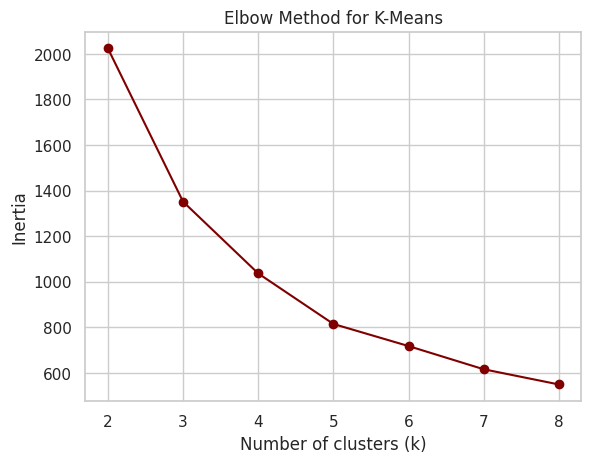

In [96]:
# Elbow
from sklearn.cluster import KMeans
inertia = []
K = range(2, 9)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o', color='maroon')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')
plt.show()

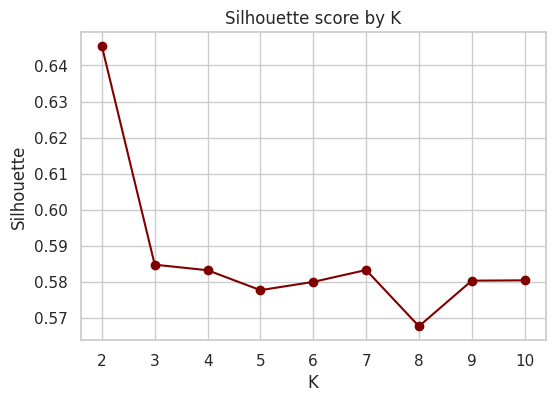

Best K (by silhouette): 2


In [97]:
# Silhouette
plt.figure(figsize=(6,4))
plt.plot(results["K"], results["silhouette"], marker="o", color="maroon")
plt.title("Silhouette score by K")
plt.xlabel("K"); plt.ylabel("Silhouette")
plt.show()

best_k = int(results.loc[results["silhouette"].idxmax(), "K"])
print("Best K (by silhouette):", best_k)


Elbow and silhouette diagnostics were computed for K=2–10. The silhouette score peaks at K=2 (0.645) and the elbow curve flattens after the first split, so I select K=2 for a simple, easy-to-interpret two-regime clustering.

In [98]:
X = age_main[["age_difference"]].values
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
age_km = age_main.copy()
age_km["cluster"] = km.fit_predict(X)

# interpret clusters
summary = (age_km.groupby("cluster")["age_difference"]
           .agg(n="count", mean="mean", median="median", min="min", max="max")
           .sort_values("mean"))
display(summary)

# label clusters as Small/Medium/Large by mean
labels_map = {summary.index[0]: "Small-gap", summary.index[-1]: "Large-gap"}
age_km["regime"] = age_km["cluster"].map(labels_map)

# compare regimes by pairing
regime_by_pair = pd.crosstab(age_km["pairing"], age_km["regime"], normalize="index") * 100
display(regime_by_pair.round(1))

,n,mean,median,min,max
cluster,,,,,
0,832,6.164663,6.0,0,14
1,300,22.016667,20.0,15,52


regime,Large-gap,Small-gap
pairing,,
man–woman,30.8,69.2
woman–man,6.9,93.1


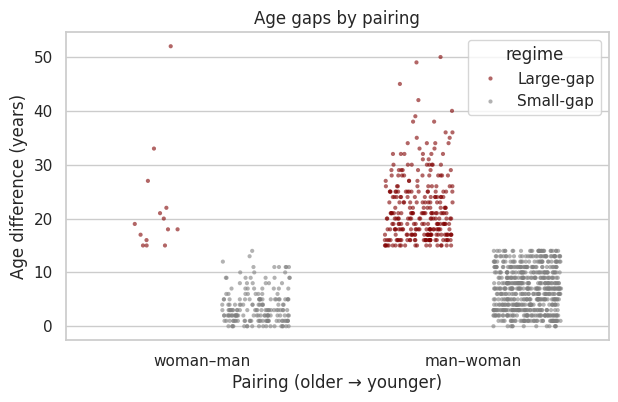

In [99]:
plt.figure(figsize=(7,4))
sns.stripplot(
    data=age_km,
    x="pairing", y="age_difference", hue="regime", palette={"Large-gap": "maroon", "Small-gap": "gray"},dodge=True, jitter=0.25, alpha=0.6, size=3
)
plt.title("Age gaps by pairing")
plt.xlabel("Pairing (older → younger)")
plt.ylabel("Age difference (years)")
plt.show()

With K = 2, the clusters are clearly interpretable: a small-gap regime (0–14 years; mean ≈ 6.16, median = 6; n = 832) and a large-gap regime (15–52 years; mean ≈ 22.02, median = 20; n = 300). The dot plot shows that man–woman pairings fall into the large-gap regime much more often (30.8%) than woman–man pairings (6.9%).

This unsupervised result supports the idea that large age gaps are not evenly distributed across pairing types and are more common when the older partner is a man.


Limitation: K-means imposes hard boundaries on a continuous distribution, so the regimes are a simplification—but they provide a useful, label-free robustness check.

##Method 2 (Unsupervised): Hierarchical clustering as a robustness check

To check that the K-means “small-gap vs large-gap” result is not algorithm-specific, I run hierarchical clustering on `age_difference`.  
This gives an independent clustering of age gaps, so I can again compare how often man–woman vs woman–man pairings fall into the large-gap regime.

In [100]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

X = age_main[["age_difference"]].values

scores_h = {}
for k in range(2, 7):
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X)
    scores_h[k] = silhouette_score(X, labels)

sil_h = pd.DataFrame({"K": list(scores_h.keys()), "silhouette": list(scores_h.values())}).sort_values("K")
display(sil_h)

best_k_h = max(scores_h, key=scores_h.get)
print("Best K (hierarchical) based on silhouette:", best_k_h)

,K,silhouette
0,2,0.642606
1,3,0.606425
2,4,0.571288
3,5,0.563904
4,6,0.564923


Best K (hierarchical) based on silhouette: 2


The silhouette scores are highest at K = 2 (0.6426), so hierarchical clustering also supports a two-regime structure in age gaps. This is consistent with the K-means result and suggests the pattern is not dependent on one algorithm.

In [102]:
# Fit final hierarchical model
k = best_k_h
hc = AgglomerativeClustering(n_clusters=k, linkage="ward")

age_h = age_main.copy()
age_h["h_cluster"] = hc.fit_predict(X)

# Interpret clusters by typical gap size (sort by mean)
h_summary = (
    age_h.groupby("h_cluster")["age_difference"]
    .agg(n="count", mean="mean", median="median", min="min", max="max")
    .reset_index()
    .sort_values("mean")
)
display(h_summary)

# Label clusters as regimes (Small/Medium/Large) based on sorted mean
clusters_sorted = h_summary["h_cluster"].tolist()
labels_map = {clusters_sorted[0]: "Small-gap"}
if len(clusters_sorted) > 2:
    for c in clusters_sorted[1:-1]:
        labels_map[c] = "Medium-gap"
labels_map[clusters_sorted[-1]] = "Large-gap"

age_h["regime"] = age_h["h_cluster"].map(labels_map)

# Compare regime distribution within each pairing type (row %)
regime_by_pair_h = pd.crosstab(age_h["pairing"], age_h["regime"], normalize="index") * 100
display(regime_by_pair_h.round(1))


,h_cluster,n,mean,median,min,max
1,1,802,5.871571,5.0,0,13
0,0,330,21.287879,20.0,14,52


regime,Large-gap,Small-gap
pairing,,
man–woman,33.9,66.1
woman–man,7.4,92.6


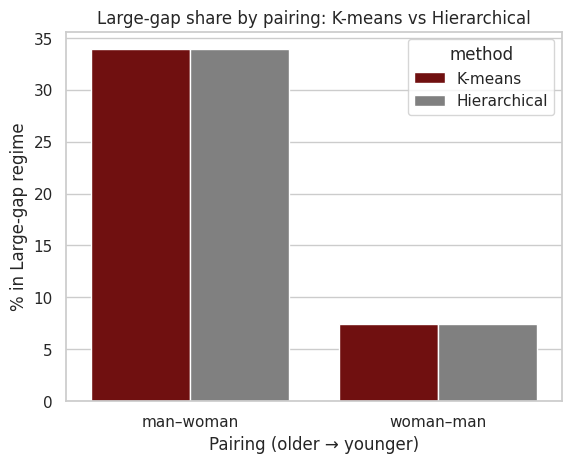

In [103]:
compare = pd.DataFrame({
    "pairing": ["man–woman", "woman–man", "man–woman", "woman–man"],
    "method": ["K-means", "K-means", "Hierarchical", "Hierarchical"],
    "pct_large": [33.9, 7.4, 33.9, 7.4]
})

palette = {"K-means": "maroon", "Hierarchical": "grey"}
sns.barplot(data=compare, x="pairing", y="pct_large", hue="method", palette=palette)
plt.ylabel("% in Large-gap regime")
plt.xlabel("Pairing (older → younger)")
plt.title("Large-gap share by pairing: K-means vs Hierarchical")
plt.show()

Both K-means and hierarchical clustering identify a clear two-regime structure in age gaps (small vs large). The bar chart shows that the main conclusion is consistent across methods: man–woman pairings have a much higher share in the large-gap regime (31–34%) than woman–man pairings (~7%). Because two different clustering approaches produce the same pattern, the result looks stable and not driven by a single algorithm choice.

Limitation: Clustering simplifies a continuous distribution into categories, but it is still useful for comparing how often each pairing falls into “large-gap” vs “small-gap.

---
# PART IV: Next Steps


**Current Gaps and Limitations**
*   I haven’t tested whether the pairing asymmetry is stable across time (by `release_year` / `decade`).
*   I haven’t quantified uncertainty for the median gap and “large-gap regime” shares.
*   I haven’t done a structured review of which specific movies drive the extreme tail (`movie_name`).
*   Same-gender pairings remain low-sample, so strong conclusions for them are still unresolved.

**Planned Next Steps**

* Compare man–woman vs woman–man within each decade (medians + regime shares).
* Bootstrap the difference in medians and the difference in large-gap proportions to show how stable the gap is.
* Summarize the top extreme-gap films and check if they cluster in certain decades.

**Unresolved Questions**

1. Is the asymmetry shrinking or growing over decades?
2. Are results driven by a few extreme films or broadly distributed?
3. What can/can’t be said about same-gender pairings with current sample sizes?

**Findings**

Since both clustering methods found a stable two-regime structure and both show a much higher large-gap share for man–woman, next steps focus on when the asymmetry is strongest and what drives the extreme tail.


----
#PART V: Conclusion

**What this notebook accomplishes:**
- Completed clean, question-driven EDA focused on `age-gap` differences by pairing type

- Validated key assumptions (age gap consistency and older → younger pairing interpretation)

- Identified major data challenges (pairing imbalance and a long-tailed `age-gap` distribution) and adjusted scope accordingly

- Applied two unsupervised methods (K-means and hierarchical clustering) to discover “`small-gap` vs `large-gap`” regimes

- Showed that the `large-gap` regime is much more common in man–woman pairings than woman–man pairings, supporting evidence of systematic gender asymmetry in casting age gaps


